# **PROJECT 7:** AI-Powered Plant Disease Detection with Generative AI Explanations

### **Step-1: Upload the saved model zip file (downloaded from Teachable Machine) in Google Colab**

In [4]:
#@title Upload the saved model zip file and Run this cell to Unzip it

import os
from IPython.display import clear_output

# Get all .zip files in the current folder
zip_files = [f for f in os.listdir('.') if f.endswith('.zip')]

if not zip_files:
    print("Please upload the saved model zip file (downloaded from Teachable Machine) in Google Colab.")
else:
    !unzip "$(ls | grep '.zip')"
    clear_output()
    print("Model Unzipped successfully!")

Model Unzipped successfully!


### **Step-2: Load Model and Class Labels**

In [5]:
#@title Run this cell to Import required libraries

import tensorflow as tf
from PIL import Image, ImageOps
import numpy as np
# Disable scientific notation for clarity
np.set_printoptions(suppress=True)

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
#@title Run this cell to Load the SavedModel

# ----------------------------
# Load SavedModel
# ----------------------------
saved_model = tf.saved_model.load("model.savedmodel")

# Get the serving function
infer = saved_model.signatures["serving_default"]

print("Model loaded successfully!")

Model loaded successfully!


In [7]:
#@title Run this cell to Load Class labels

class_names = open("labels.txt", "r").readlines()
class_names = [name.split()[-1] for name in class_names]

print("Class labels loaded successfully!")
print(class_names)

Class labels loaded successfully!
['Apple_Scab', 'Apple_Healthy', 'Potato_Early_Blight', 'Potato_Healthy', 'Tomato_Leaf_Mold', 'Tomato_Healthy']


### **Step-3: Upload a Test image and Get Prediction**

array([[[151, 147, 182],
        [152, 148, 183],
        [153, 149, 184],
        ...,
        [163, 130, 161],
        [164, 131, 162],
        [163, 130, 161]],

       [[153, 149, 184],
        [153, 149, 184],
        [153, 149, 184],
        ...,
        [167, 134, 165],
        [165, 132, 163],
        [161, 128, 159]],

       [[152, 148, 183],
        [151, 147, 182],
        [149, 145, 180],
        ...,
        [169, 136, 167],
        [165, 132, 163],
        [161, 128, 159]],

       ...,

       [[111, 105, 141],
        [113, 107, 143],
        [116, 110, 146],
        ...,
        [105,  64,  96],
        [104,  63,  95],
        [103,  62,  94]],

       [[110, 104, 140],
        [111, 105, 141],
        [111, 105, 141],
        ...,
        [100,  59,  91],
        [ 98,  57,  89],
        [ 97,  56,  88]],

       [[115, 109, 145],
        [114, 108, 144],
        [113, 107, 143],
        ...,
        [ 99,  58,  90],
        [ 99,  58,  90],
        [ 99,  58,  90]]], dtype=uint8)
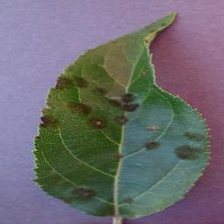

In [8]:
#@title Upload a Plant Leaf Test image, provide its file name, then Run this cell

# "Upload a test image in Colab and provide its file name here (eg. Apple_scab_test_1.JPG)"
img_file = "Apple_scab_test_1.JPG"  #@param {type:"string"}

# Prepare the input image
data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)

image = Image.open(img_file).convert("RGB")
size = (224, 224)
image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)

image_array = np.asarray(image)
normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1
data[0] = normalized_image_array

# Show image
image_array

In [9]:
#@title Run this cell to Get Prediction for the test image

# ----------------------------
# Run Prediction
# ----------------------------
# Convert numpy → tensor
input_tensor = tf.convert_to_tensor(data)

# Call the SavedModel signature
output = infer(input_tensor)

# SavedModel may return a dict – get the first output tensor
prediction = list(output.values())[0].numpy()

# Decode prediction
index = np.argmax(prediction)
class_name = class_names[index].strip()
confidence_score = prediction[0][index]

# Print results
print("Class:", class_name)
print("Confidence Score:", confidence_score)


Class: Apple_Scab
Confidence Score: 0.9999348


### **Step-4: Provide the Google Gemini API Key**

* Use an existing Google Gemini API key, or Create a new one by:
    * Visiting https://ai.google.dev/gemini-api/docs, and
    * Clicking on *Get a Geminin API key*
    * Note that Google Gemini's Free plan includes limited access to certain models



In [11]:
#@title Enter your Gemini API Key
import os

GEMINI_API_KEY = input("Enter your Gemini API Key: ")
os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY



### **Step-5: Define prompt to feed to an LLM to get farmer-friendly explanations, treatment recommendations, and optional multilingual support for regional accessibility.**

Adjust the prompt as required.

In [12]:
# ----------------------------
# Define Prompt
# ----------------------------

language = "English"

# Prompt For Response Generation
prompt = f"""
You are an expert Agricultural plant pathologist and crop-health advisor.
Explain the condition {class_name} and provide practical, safe, and easy-to-apply remedies.

Include:

- A brief explanation of the disease
- Key symptoms
- Immediate actions a farmer/gardener should take
- Natural or low-cost remedies
- When to consider chemical treatments
- Preventive measures for future crops**

Symptom: {class_name}

Answer only in {language}.

If the plant is unhealthy, then start the response in this format:
`**Plant:** <plant-name>
 **Status:** Unhealthy
 **Disease:** <disease-name>`

If the plant is healthy, then respond in this format:
`**Plant:** <plant-name>
 **Status:** Healthy`
"""

print("\nPROMPT\n" + "="*100)
print(prompt)


PROMPT

You are an expert Agricultural plant pathologist and crop-health advisor.
Explain the condition Apple_Scab and provide practical, safe, and easy-to-apply remedies.

Include:

- A brief explanation of the disease
- Key symptoms
- Immediate actions a farmer/gardener should take
- Natural or low-cost remedies
- When to consider chemical treatments
- Preventive measures for future crops**

Symptom: Apple_Scab

Answer only in English.

If the plant is unhealthy, then start the response in this format:
`**Plant:** <plant-name>
 **Status:** Unhealthy
 **Disease:** <disease-name>`

If the plant is healthy, then respond in this format:
`**Plant:** <plant-name>
 **Status:** Healthy`



### **Step-6: Make an LLM API call using the above prompt**

In [13]:
#@title Run this cell to Make an LLM API Call

# ----------------------------
# Make an LLM Call
# ----------------------------

# Initialize Client
from google import genai
gemini_client = genai.Client()


# Make API call and get response
gemini_response = gemini_client.models.generate_content(
    model="gemini-2.5-flash",
    contents=prompt,
)

# Show response in Markdown
from IPython.display import Markdown

Markdown(gemini_response.text)

**Plant:** Apple
**Status:** Unhealthy
**Disease:** Apple Scab

As an expert agricultural plant pathologist, I can confirm that Apple Scab is a common and often frustrating disease for apple growers. Let's break down this condition and explore effective management strategies.

### A Brief Explanation of the Disease

Apple Scab is caused by the fungus *Venturia inaequalis*. It is one of the most widespread and economically important diseases of apples and crabapples worldwide. The fungus thrives in cool, wet conditions, particularly during spring and early summer. It overwinters primarily in fallen infected leaves on the orchard floor. In spring, as temperatures rise and moisture is present, spores (ascospores) are released from these overwintered leaves and carried by wind to newly emerging apple tissues (leaves, flowers, young fruit). Once established, new generations of spores (conidia) are produced directly on the lesions, leading to secondary infections throughout the growing season, especially during periods of wet weather.

### Key Symptoms

Apple Scab manifests differently on various parts of the apple tree:

*   **Leaves:** The most common symptom. Small, olive-green to brown, velvety spots first appear, often on the undersides of young leaves. As the lesions mature, they darken, become more prominent, and may cause the leaves to crinkle, distort, turn yellow, and drop prematurely.
*   **Fruit:** Initially, small, olive-green spots develop, similar to those on leaves. As these lesions age, they become corky, dark brown to black, rough, and sunken, giving the fruit a characteristic "scabby" appearance. Early infections can cause fruit distortion, cracking, and premature drop. Scabs can also make the fruit more susceptible to secondary rot organisms during storage.
*   **Twigs/Shoots:** Less common, but lesions can appear as small, blister-like swellings that may rupture, revealing a velvety, spore-producing mass. These cankers can sometimes girdle and kill young shoots.
*   **Flowers:** Infected flowers may show spots on petals or sepals, leading to browning and premature drop, which can reduce the overall fruit set.

### Immediate Actions a Farmer/Gardener Should Take

Upon noticing symptoms of Apple Scab, swift action is crucial to limit its spread and impact:

1.  **Sanitation is Key:** Immediately rake up and destroy all fallen leaves and any infected fruit from beneath the apple trees. This is the single most important step you can take right now, as it removes the primary source of overwintering inoculum. Bag them and dispose of them, do not compost them unless you have a very hot composting system.
2.  **Prune Infected Twigs:** If you observe any infected twigs or shoots (they'll have visible lesions or cankers), prune them out. Make clean cuts into healthy wood and dispose of the infected material away from the orchard. Sanitize your pruning tools between cuts with a 10% bleach solution or rubbing alcohol to prevent further spread.
3.  **Improve Air Circulation:** Prune the tree canopy to allow for better air movement and light penetration. This helps leaves dry faster after rain or dew, creating an environment less favorable for fungal growth. Remove crossing branches, water sprouts, and suckers.

### Natural or Low-Cost Remedies

For mild to moderate infections, or as part of an integrated pest management strategy, several natural and low-cost options can be employed:

*   **Continued Sanitation:** Reiterate the importance of diligently removing all plant debris. This remains the cornerstone of non-chemical management.
*   **Neem Oil:** Apply neem oil sprays (following label instructions) which have some fungicidal properties. It can help disrupt the fungal life cycle and deter spore germination. Best used preventatively or at the first sign of disease.
*   **Horticultural Oil / Mineral Oil Sprays:** Some horticultural oils can provide a barrier effect and smother spores, but their primary use is often for insect control. They might offer limited fungicidal benefits, especially when mixed with other agents.
*   **Sulfur-based Fungicides:** Elemental sulfur is an organic fungicide that can be effective against apple scab. However, it must be applied preventatively or at the very early stages of infection. Be cautious with sulfur in hot weather (above 85°F/29°C), as it can cause phytotoxicity (burn foliage) on some apple varieties. Always check label instructions for specific varieties and temperature restrictions.
*   **Baking Soda Spray (Potassium Bicarbonate):** A homemade solution of 1 tablespoon of baking soda (or potassium bicarbonate, which is more effective) mixed with 1 teaspoon of horticultural oil or liquid soap per gallon of water can act as a contact fungicide by altering the pH on the leaf surface. This needs to be applied frequently (every 7-10 days, especially after rain) and thoroughly to all affected surfaces. Its effectiveness is limited to very light infections or as a preventative.

### When to Consider Chemical Treatments

Chemical treatments, specifically synthetic fungicides, should be considered when:

*   **Disease Pressure is High:** If the climate is consistently cool and wet during spring and early summer, or if previous seasons have seen severe scab outbreaks, chemical treatment may be necessary to protect the crop.
*   **Natural Methods are Insufficient:** When natural remedies and cultural practices are not enough to control the disease and significant crop loss or tree health decline is evident.
*   **Commercial Production:** Commercial orchards often rely on well-timed fungicide applications due to the economic implications of significant scab damage.
*   **Critical Timing:** Fungicides are most effective when applied preventatively, before or during critical infection periods. This usually means from bud break through petal fall and into early fruit development (the first 4-6 weeks after bloom are crucial).
    *   **Contact Fungicides:** Form a protective barrier on the plant surface (e.g., Captan, Mancozeb). They need to be reapplied after heavy rains.
    *   **Systemic Fungicides:** Are absorbed into the plant tissue, offering longer protection and some eradicant (kickback) activity (e.g., Myclobutanil for home gardens; DMI fungicides for commercial use).
*   **Consult Local Extension:** Always consult your local agricultural extension office for specific product recommendations, application timings, and resistance management strategies tailored to your region and apple varieties. They can provide accurate forecasts for scab infection periods. Always follow label instructions meticulously for safety and efficacy.

### Preventive Measures for Future Crops

Prevention is undoubtedly the most effective long-term strategy against Apple Scab:

1.  **Plant Resistant Varieties:** This is the single most impactful long-term solution. Choose apple varieties that are naturally resistant or immune to Apple Scab. Examples include 'Liberty', 'Freedom', 'Goldrush', 'CrimsonCrisp', 'Enterprise', 'Pristine', 'William's Pride', and 'Redfree'.
2.  **Thorough Fall Cleanup:** Continue to religiously rake and remove *all* fallen leaves and debris from under apple trees in the autumn. This removes the overwintering inoculum, drastically reducing primary infections in the spring. Chopping fallen leaves with a mower can also help them decompose faster, reducing viable spores.
3.  **Proper Pruning:** Maintain an open canopy through regular, annual pruning. This improves air circulation, allowing foliage to dry quickly, which inhibits fungal spore germination and growth.
4.  **Optimal Site Selection:** Plant apple trees in locations with full sun, good air circulation, and well-drained soil. Avoid low-lying, poorly drained areas where humidity tends to linger.
5.  **Appropriate Watering:** Water at the base of the tree, using drip irrigation or soaker hoses, rather than overhead sprinklers, which wet the foliage and create ideal conditions for fungal spread. Water in the morning to allow any splashed water to dry quickly.
6.  **Mulch:** Apply a fresh layer of mulch (e.g., wood chips, straw) under apple trees in the spring. This acts as a physical barrier, preventing any remaining overwintered spores from splashing up onto new growth.
7.  **Monitor Regularly:** Be vigilant, especially during cool, wet springs. Regular inspection of leaves and developing fruit for early signs of scab can allow for timely intervention before the disease becomes widespread.

By combining these strategies, you can significantly reduce the incidence and severity of Apple Scab, promoting healthier trees and a more bountiful harvest.

### **Step-7: Create a Gradio Interface**

Use the Gemini present within Google Colab notebook ( <img src='https://drive.google.com/uc?id=19N2vjh7eihxQ3qj9uavYblyveidsLKsf' width=30> ), to generate code for creating a Gradio Interface with below features.



Inputs:
- `Gradio File` to let user upload an image file
- `Gradio Textbox` to let user enter his preferred Language

Outputs:
- `Gradio Image` to show the image uploaded by user
- `Gradio Markdown` to render the LLM response

Logic:
- The user input image should go to the plant disease detection model (trained on Teachable Machine)
- The predicted disease-label and the user preferred language should become part of the prompt
- Use an LLM to generate farmer-friendly explanations, treatment guidance, and preventive steps


In [14]:
import gradio as gr
import tensorflow as tf
from PIL import Image, ImageOps
import numpy as np
from google import genai
import os

# Ensure GEMINI_API_KEY is set (from previous cell)
os.environ['GEMINI_API_KEY'] = GEMINI_API_KEY # Re-setting for clarity within function context
gemini_client = genai.Client() # Re-initializing for clarity within function context

def predict_disease_and_explain(image_file, language_input):
    # 1. Prepare the input image for the model
    data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
    # Gradio image_file is a tempfile object with a .name attribute for the path
    image = Image.open(image_file.name).convert("RGB")
    size = (224, 224)
    image_resized = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
    image_array = np.asarray(image_resized)
    normalized_image_array = (image_array.astype(np.float32) / 127.5) - 1
    data[0] = normalized_image_array

    # 2. Run Prediction with the model
    input_tensor = tf.convert_to_tensor(data)
    output = infer(input_tensor)
    prediction = list(output.values())[0].numpy()
    index = np.argmax(prediction)
    class_name = class_names[index].strip()
    confidence_score = prediction[0][index]

    # 3. Construct the LLM prompt
    if "Healthy" in class_name:
        plant_name = class_name.replace("_Healthy", "")
        prompt_for_llm = f"""
You        You are an expert Agricultural plant pathologist and crop-health advisor.
        Explain the condition {class_name}.

        Include:

        - A brief explanation of the healthy condition
        - What does it mean for a plant to be healthy
        - General tips for maintaining plant health
        - How to prevent common issues

        Symptom: {class_name}

        Answer only in {language_input}.

        Respond in this format:
        `**Plant:** {plant_name}
         **Status:** Healthy
         **Confidence:** {confidence_score*100:.2f}%`
        """
    else:
        # Assuming disease names are like "Apple_Scab", "Potato_Early_Blight"
        parts = class_name.split('_')
        if len(parts) > 1:
            plant_name = parts[0]
            disease_name = class_name # Use full class_name as disease
        else:
            plant_name = "Plant" # Default if unable to parse
            disease_name = class_name

        prompt_for_llm = f"""
        You are an expert Agricultural plant pathologist and crop-health advisor.
        Explain the condition {class_name} and provide practical, safe, and easy-to-apply remedies.

        Include:

        - A brief explanation of the disease
        - Key symptoms
        - Immediate actions a farmer/gardener should take
        - Natural or low-cost remedies
        - When to consider chemical treatments
        - Preventive measures for future crops**

        Symptom: {class_name}

        Answer only in {language_input}.

        Respond in this format:
        `**Plant:** {plant_name}
         **Status:** Unhealthy
         **Disease:** {disease_name}
         **Confidence:** {confidence_score*100:.2f}%`
        """

    # 4. Make an LLM API call
    gemini_response = gemini_client.models.generate_content(
        model="gemini-2.5-flash",
        contents=prompt_for_llm,
    )

    # 5. Return results for Gradio outputs
    # Gradio image output expects a file path, numpy array, or PIL Image
    # Gradio markdown output expects a string
    return image, gemini_response.text

# Define the Gradio Interfacewa
iface = gr.Interface(
    fn=predict_disease_and_explain,
    inputs=[
        gr.File(label="Upload a Plant Leaf Image"),
        gr.Textbox(label="Enter Preferred Language", value="English")
    ],
    outputs=[
        gr.Image(label="Uploaded Image"),
        gr.Markdown(label="AI-Powered Explanation and Guidance")
    ],
    title="AI-Powered Plant Disease Detection with Generative AI Explanations",
    description="Upload a plant leaf image and get disease detection, farmer-friendly explanations, and treatment recommendations in your preferred language."
)

# Launch the Gradio interface
iface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://60befb277fe049f40a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


This code creates a simple Gradio interface:

*   `upload_image` is a function that takes the uploaded file object and returns its name.
*   `gr.File(label="Upload an Image")` creates an input component allowing users to upload a file.
*   `gr.Textbox(label="Uploaded File Path")` displays the path of the uploaded file.

To run this interface, uncomment `iface.launch()` in the code and execute the cell.

In [ ]:
import gradio as gr

---

<center>
$END$
</center>

---